# 🎾 ATP Tennis GOAT Debate — What Does the Data Actually Say?

**Dataset:** ATP Tennis 2000–2023 | **Source:** Kaggle | **Tools:** Python, pandas, matplotlib, seaborn

---

## Background

The Federer–Nadal–Djokovic GOAT debate is one of the loudest arguments in sports. Djokovic now holds the most Grand Slam titles, but a common counter-argument goes something like this:

> *"Djokovic only racked up those titles because Federer and Nadal were already past their prime. The competition wasn't the same."*

It's a reasonable thing to wonder. It's also the kind of claim that tends to get repeated without anyone actually checking the numbers. So I did.

---

## What I'm Trying to Answer

Three questions, roughly in order of complexity:

**1. When were each of the Big 3 actually at their peak?**
Before we can argue about whether someone faced "weakened" competition, we need to establish when each player was prime — and whether those windows overlapped.

**2. How did they perform head-to-head, and when?**
If Djokovic consistently beat Federer and Nadal even during their peak years, the "they were already declining" argument gets a lot harder to make.

**3. How hard were those wins, really?**
Win totals don't tell the whole story. Who did they beat to get there? Were those matches close? Did they win as favorites or as underdogs?

---

## The Dataset

| | |
|---|---|
| **Source** | [Kaggle — ATP Tennis 2000–2023](https://www.kaggle.com/datasets/dissfya/atp-tennis-2000-2023daily-pull) |
| **Coverage** | ATP tour matches from 2000 to 2023 |
| **Rows** | Match-level data (one row per match) |
| **Key columns** | `Player_1`, `Player_2`, `Winner`, `Rank_1`, `Rank_2`, `Tournament`, `Series`, `Surface`, `Round`, `Score`, `Date`, `Odd_1`, `Odd_2` |

The dataset for this project is included in the `Dataset` folder. The data is based on the version 1053 that is downloaded in 29 March 2026. A more updated data should not make a significant changes on the result of this analysis as Novak Djokovic is the only remain active player among the others 2 (Nadal and Federer).

---

## Section 0: Setup & Data Loading
Libraries, loading the CSV, first look at the data.

In [1]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime

# Visual style — dark terminal aesthetic
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.facecolor']   = '#1a1a1a'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = '#cccccc'
plt.rcParams['xtick.color']      = '#888888'
plt.rcParams['ytick.color']      = '#888888'
plt.rcParams['text.color']       = '#cccccc'
plt.rcParams['grid.color']       = '#2a2a2a'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['font.family']      = 'monospace'

BIG3_COLORS = {
    'Federer R.' : '#4fc3f7',   # blue
    'Nadal R.'   : '#ef5350',   # red
    'Djokovic N.': '#66bb6a',   # green
}

In [2]:
# Loading the data

df = pd.read_csv('Dataset/atp_tennis_260329.csv', low_memory=False)

print("Shape      :", df.shape)
print("Date range :", df['Date'].min(), "→", df['Date'].max())
df.head(3)

Shape      : (67288, 17)
Date range : 2000-01-03 → 2026-03-15


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1,6-4 6-2
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1,3-6 3-6
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,Escude N.,40,655,-1,-1,-1.0,-1,6-7 7-5 6-3


## Section 1: Cleaning & Feature Engineering
Deriving what we need: match year, age at match time, Grand Slam flag, and match difficulty (straight sets vs. extended matches).

In [3]:
# Fix types
df['Date']  = pd.to_datetime(df['Date'])
df['Odd_2'] = pd.to_numeric(df['Odd_2'], errors='coerce')

# Replace -1 placeholders with NaN
for col in ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']:
    df[col] = df[col].replace(-1, np.nan)

# Derive: Year
df['Year'] = df['Date'].dt.year

# Derive: Is_Grand_Slam
df['Is_Grand_Slam'] = df['Series'] == 'Grand Slam'

# Derive: Age at match time
BIRTHDATES = {
    'Federer R.' : pd.Timestamp('1981-08-08'),
    'Nadal R.'   : pd.Timestamp('1986-06-03'),
    'Djokovic N.': pd.Timestamp('1987-05-22'),
}

def get_age(player_name, match_date):
    if player_name not in BIRTHDATES:
        return np.nan
    return (match_date - BIRTHDATES[player_name]).days / 365.25

df['Age_P1'] = df.apply(lambda r: get_age(r['Player_1'], r['Date']), axis=1)
df['Age_P2'] = df.apply(lambda r: get_age(r['Player_2'], r['Date']), axis=1)

# Derive: Match Difficulty
def match_difficulty(row):
    try:
        score    = str(row['Score']).split('RET')[0].split('W/O')[0].strip()
        sets     = len(score.strip().split())
        best_of  = int(row['Best of'])
        if best_of == 3:
            return 'Extended' if sets == 3 else 'Straight Sets'
        elif best_of == 5:
            return 'Extended' if sets >= 4 else 'Straight Sets'
        return np.nan
    except:
        return np.nan

df['Match_Difficulty'] = df.apply(match_difficulty, axis=1)

# Derive: Big 3 flags
BIG3 = list(BIG3_COLORS.keys())
df['P1_is_Big3'] = df['Player_1'].isin(BIG3)
df['P2_is_Big3'] = df['Player_2'].isin(BIG3)
df['Is_H2H']     = df['P1_is_Big3'] & df['P2_is_Big3']

# Derive: Loser column
df['Loser'] = df.apply(
    lambda r: r['Player_2'] if r['Winner'] == r['Player_1'] else r['Player_1'], axis=1
)
df['Winner_is_Big3'] = df['Winner'].isin(BIG3)

# Derive: Winner/Loser Rank & Odds
df['Winner_Rank'] = df.apply(lambda r: r['Rank_1'] if r['Winner'] == r['Player_1'] else r['Rank_2'], axis=1)
df['Loser_Rank']  = df.apply(lambda r: r['Rank_2'] if r['Winner'] == r['Player_1'] else r['Rank_1'], axis=1)
df['Winner_Odd']  = df.apply(lambda r: r['Odd_1'] if r['Winner'] == r['Player_1'] else r['Odd_2'], axis=1)
df['Loser_Odd']   = df.apply(lambda r: r['Odd_2'] if r['Winner'] == r['Player_1'] else r['Odd_1'], axis=1)

# Derive: Underdog win
df['Underdog_Win'] = df['Winner_Odd'] > df['Loser_Odd']

print("Cleaning done. New columns added:", [c for c in df.columns if c not in ['Tournament','Date','Series','Court','Surface','Round','Best of','Player_1','Player_2','Winner','Rank_1','Rank_2','Pts_1','Pts_2','Odd_1','Odd_2','Score']])

Cleaning done. New columns added: ['Year', 'Is_Grand_Slam', 'Age_P1', 'Age_P2', 'Match_Difficulty', 'P1_is_Big3', 'P2_is_Big3', 'Is_H2H', 'Loser', 'Winner_is_Big3', 'Winner_Rank', 'Loser_Rank', 'Winner_Odd', 'Loser_Odd', 'Underdog_Win']


In [4]:
# Sanity check

print(f"Total matches      : {len(df):,}")
print(f"Grand Slam matches : {df['Is_Grand_Slam'].sum():,}")
print(f"Big 3 H2H matches  : {df['Is_H2H'].sum():,}")

print("\nBig 3 overall stats:")
for p in BIG3:
    total = ((df['Player_1'] == p) | (df['Player_2'] == p)).sum()
    wins  = (df['Winner'] == p).sum()
    print(f"  {p:<15} {total:>5} matches | {wins:>4} wins | {wins/total*100:.1f}% win rate")

Total matches      : 67,288
Grand Slam matches : 12,632
Big 3 H2H matches  : 140

Big 3 overall stats:
  Federer R.       1393 matches | 1151 wins | 82.6% win rate
  Nadal R.         1214 matches | 1007 wins | 82.9% win rate
  Djokovic N.      1268 matches | 1065 wins | 84.0% win rate


### Initial Observations

A few things worth noting before we go further.

Win rates across all three players are remarkably close — Federer at 82.6%, 
Nadal at 82.9%, and Djokovic at 84.0%, across 1,200+ matches each. 
The gap is real but much smaller than the GOAT debate rhetoric usually implies.

The dataset contains 140 direct Big 3 head-to-head matches, which is a solid 
sample size for the H2H analysis in Section 3.

A few dataset limitations worth being upfront about. First, Federer's data runs 
through July 2021 (age 39.9), while Nadal's goes to July 2024 (age 38.1) and 
Djokovic's extends to March 2026. Federer retired in September 2022, so his 
final year on tour isn't captured here — though his peak years are well 
represented. Second, this dataset covers ATP Tour main draw matches only, which 
means H2H totals here will be slightly lower than the official ATP numbers, 
which include Davis Cup, Olympics, ATP Cup, and Laver Cup. Cross-checked against 
official records, the differences are small and the direction of every finding 
holds — but for reference:

| Matchup | This dataset | Official ATP (all competitions) |
|---|---|---|
| Djokovic vs Federer | 26–20 | 27–23 |
| Djokovic vs Nadal | 29–25 | 30–29 |
| Djokovic vs Nadal (GS only) | 7–9 | 7–11 (Nadal leads) |

---

## Section 2: The Prime Era

Before we can evaluate the **"Djokovic benefited from declining rivals"** argument,
we need to establish the facts: when was each player actually at their peak,
and did those windows overlap?

Three views on the same question: ATP ranking trajectory, Grand Slam titles per
year, and overall win rate per year.

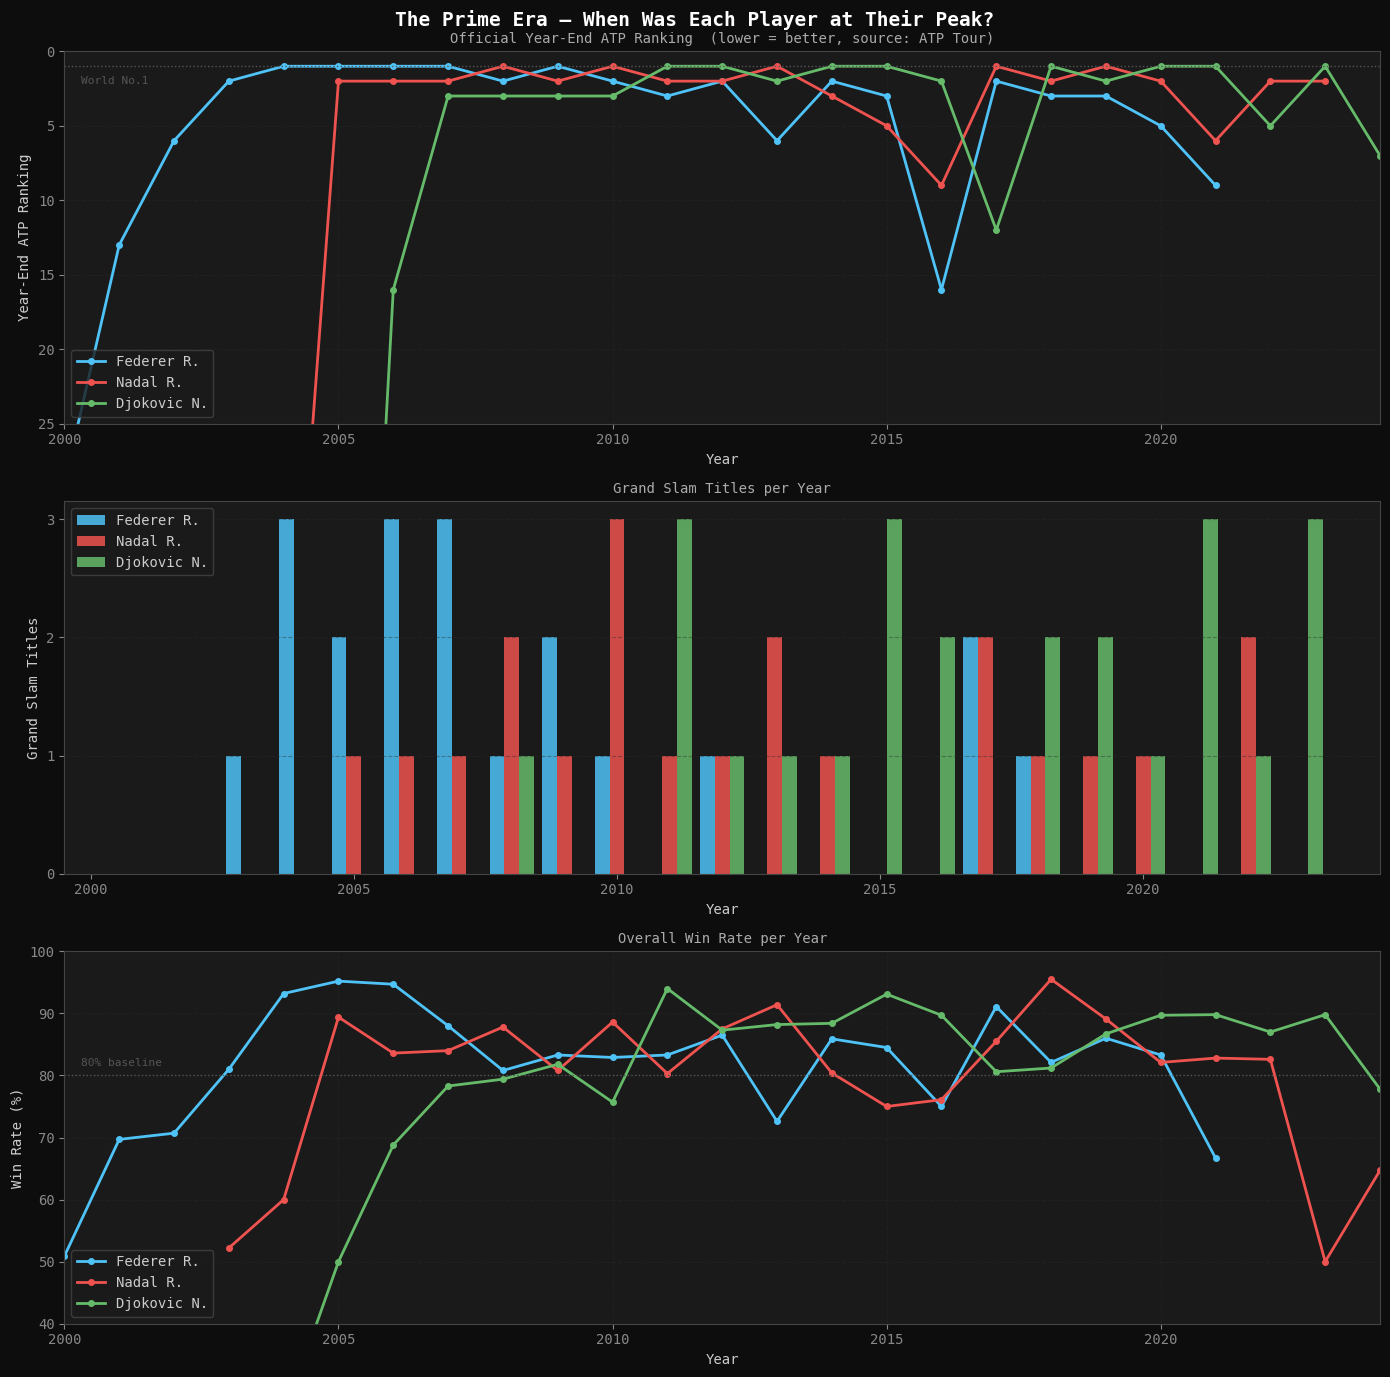

In [9]:
YEARS = list(range(2000, 2025))

# ── Ranking data ──────────────────────────────────────────────────────────────
# Year-end rankings sourced directly from official ATP records.
# We don't derive this from the dataset because the dataset captures rank at
# match time — players who retire injured mid-season (e.g. Nadal in 2018)
# retain a stale rank while the rest of the field moves around them,
# causing false overlaps at No.1. Official year-end standings fix this.
YEAR_END_RANKINGS = {
    'Federer R.': {
        2000: 29, 2001: 13, 2002: 6,  2003: 2,  2004: 1,
        2005: 1,  2006: 1,  2007: 1,  2008: 2,  2009: 1,
        2010: 2,  2011: 3,  2012: 2,  2013: 6,  2014: 2,
        2015: 3,  2016: 16, 2017: 2,  2018: 3,  2019: 3,
        2020: 5,  2021: 9,
    },
    'Nadal R.': {
        2003: 49, 2004: 51, 2005: 2,  2006: 2,  2007: 2,
        2008: 1,  2009: 2,  2010: 1,  2011: 2,  2012: 2,
        2013: 1,  2014: 3,  2015: 5,  2016: 9,  2017: 1,
        2018: 2,  2019: 1,  2020: 2,  2021: 6,  2022: 2,
        2023: 2,
    },
    'Djokovic N.': {
        2005: 83, 2006: 16, 2007: 3,  2008: 3,  2009: 3,
        2010: 3,  2011: 1,  2012: 1,  2013: 2,  2014: 1,
        2015: 1,  2016: 2,  2017: 12, 2018: 1,  2019: 2,
        2020: 1,  2021: 1,  2022: 5,  2023: 1,  2024: 7,
    },
}

rank_data = {p: pd.Series(YEAR_END_RANKINGS[p]) for p in BIG3}

# ── GS titles & win rate (still derived from dataset) ─────────────────────────
gs_data = {}
wr_data = {}
gs_finals = df[df['Is_Grand_Slam'] & (df['Round'] == 'The Final')]

for p in BIG3:
    p_df       = df[(df['Player_1'] == p) | (df['Player_2'] == p)].copy()
    gs_data[p] = gs_finals[gs_finals['Winner'] == p].groupby('Year').size()
    wins       = df[df['Winner'] == p].groupby('Year').size()
    total      = p_df.groupby('Year').size()
    wr_data[p] = (wins / total * 100).round(1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('The Prime Era — When Was Each Player at Their Peak?',
             fontsize=14, fontweight='bold', color='white', y=0.98)

# Panel 1: Official year-end ranking
ax1 = axes[0]
for p, color in BIG3_COLORS.items():
    s = rank_data[p].reindex(YEARS)
    ax1.plot(YEARS, s, color=color, linewidth=2, marker='o', markersize=4, label=p)
ax1.set_ylim(25, 0)
ax1.set_ylabel('Year-End ATP Ranking')
ax1.set_title('Official Year-End ATP Ranking  (lower = better, source: ATP Tour)',
              color='#aaaaaa', fontsize=10)
ax1.legend(loc='lower left', facecolor='#1a1a1a', edgecolor='#444444')
ax1.set_xlim(2000, 2024)
ax1.grid(True, alpha=0.4)
ax1.axhline(y=1, color='#555555', linestyle=':', linewidth=1)
ax1.text(2000.3, 2.2, 'World No.1', color='#555555', fontsize=8)

# Panel 2: Grand Slam titles per year
ax2 = axes[1]
bar_width = 0.28
offsets   = [-bar_width, 0, bar_width]
for i, (p, color) in enumerate(BIG3_COLORS.items()):
    s = gs_data[p].reindex(YEARS, fill_value=0)
    x = [y + offsets[i] for y in YEARS]
    ax2.bar(x, s, width=bar_width, color=color, alpha=0.85, label=p)
ax2.set_ylabel('Grand Slam Titles')
ax2.set_title('Grand Slam Titles per Year', color='#aaaaaa', fontsize=10)
ax2.legend(loc='upper left', facecolor='#1a1a1a', edgecolor='#444444')
ax2.set_xlim(1999.5, 2024.5)
ax2.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.grid(True, alpha=0.4, axis='y')

# Panel 3: Win rate per year
ax3 = axes[2]
for p, color in BIG3_COLORS.items():
    s = wr_data[p].reindex(YEARS)
    ax3.plot(YEARS, s, color=color, linewidth=2, marker='o', markersize=4, label=p)
ax3.set_ylabel('Win Rate (%)')
ax3.set_title('Overall Win Rate per Year', color='#aaaaaa', fontsize=10)
ax3.legend(loc='lower left', facecolor='#1a1a1a', edgecolor='#444444')
ax3.set_xlim(2000, 2024)
ax3.set_ylim(40, 100)
ax3.grid(True, alpha=0.4)
ax3.axhline(y=80, color='#555555', linestyle=':', linewidth=1)
ax3.text(2000.3, 81.5, '80% baseline', color='#555555', fontsize=8)

for ax in axes:
    ax.set_xlabel('Year')
    ax.tick_params(colors='#888888')

plt.tight_layout()
plt.show()

### What the data shows

The three charts together tell a pretty clear story.

Federer dominated from roughly **2004–2010** — five straight years at World No.1,
peaking at 3 Grand Slams in a single year (2004, 2006, 2007). After 2010 his
ranking stays competitive but he never fully reclaims that consistency. 2016 is
his worst year on record, dropping to No.16 due to injury — the most dramatic
single-year decline of any Big 3 player in the dataset.

Nadal's prime is less of a single peak and more of **two distinct waves** —
a dominant clay-era run from 2005–2011, a dip in 2015–2016 (wrist and knee
injuries), then a second resurgence from 2017–2020 where his win rate climbs
back above 85% and he returns to No.1.

Djokovic's ascent starts in 2011 and **largely never stops** — with one
notable exception. In 2017 he dropped to No.12 due to elbow injury, his
worst year since breaking through. He came back in 2018 ranked No.1 and
hasn't finished outside the top 8 since. Crucially, his biggest Grand Slam
years (2015, 2021, 2023) come *after* Federer's decline — but they
significantly overlap with Nadal's second prime.

This already complicates the "weakened competition" argument. The next section
looks at what happened when they actually played each other.

> **Note on ranking data:** Year-end rankings are sourced directly from official
> ATP records rather than derived from the dataset. The dataset captures rank at
> match time, which becomes unreliable for players who retired injured mid-season
> (e.g. Nadal in 2018) as their rank no longer reflects the true year-end standing.

---

## Section 3 — Head-to-Head

If the argument is that Djokovic's dominance came from weakened rivals, the
head-to-head record is the most direct place to check. These are the matches
where all three variables are controlled — same tournament, same conditions,
same day. One of them won and one of them lost.

Three views: cumulative wins over time, wins per year, and wins by surface.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17764\1211863063.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly  = matches.groupby('Year').apply(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17764\1211863063.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly  = matches.groupby('Year').apply(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17764\1211863063.py:38: DeprecationWarning: DataFrameGroupB

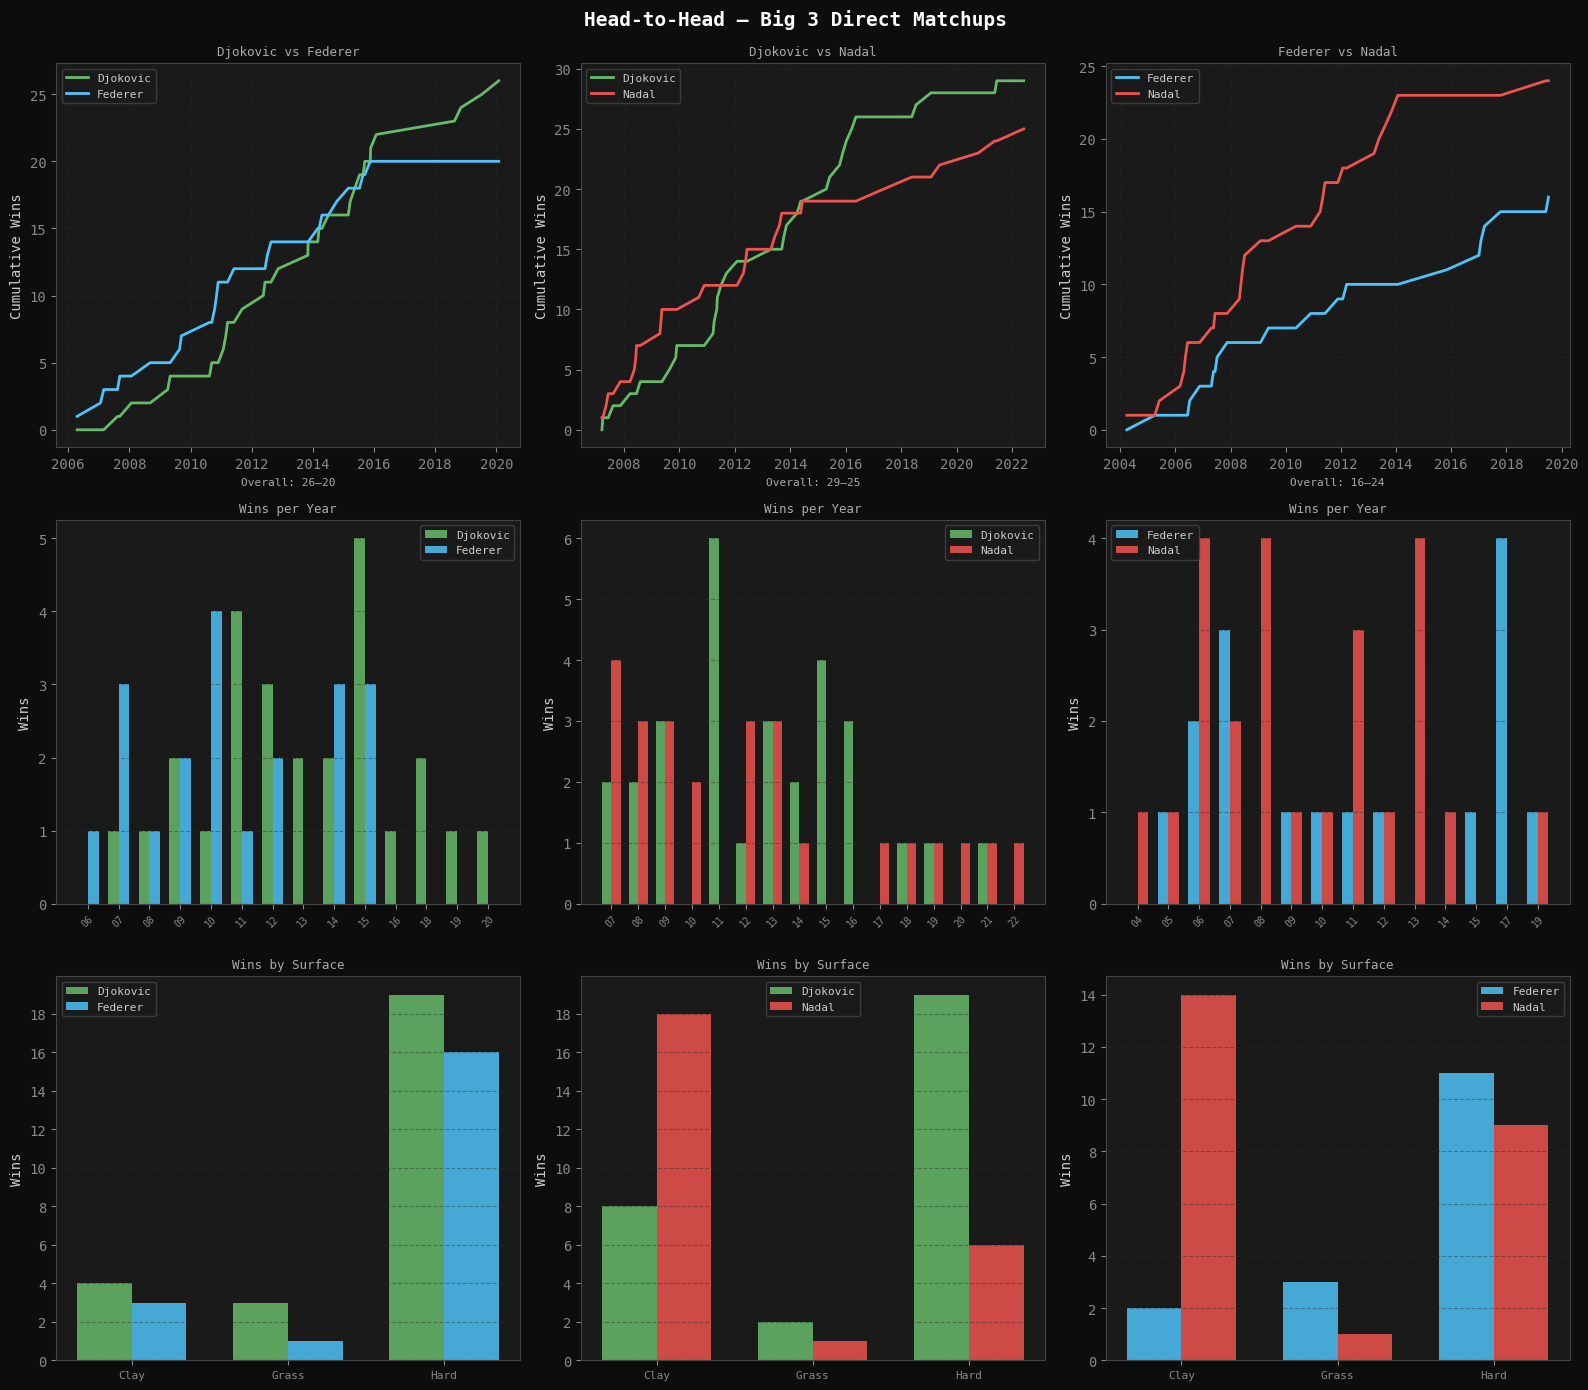

In [6]:
MATCHUPS = [
    ('Djokovic N.', 'Federer R.'),
    ('Djokovic N.', 'Nadal R.'),
    ('Federer R.',  'Nadal R.'),
]

def get_h2h(p1, p2, data=df):
    h2h = data[data['Is_H2H']]
    return h2h[
        ((h2h['Player_1']==p1)|(h2h['Player_2']==p1)) &
        ((h2h['Player_1']==p2)|(h2h['Player_2']==p2))
    ]

fig = plt.figure(figsize=(16, 14))
fig.suptitle('Head-to-Head — Big 3 Direct Matchups', fontsize=14,
             fontweight='bold', color='white', y=0.99)

# Row 1: Cumulative wins over time
for col_i, (p1, p2) in enumerate(MATCHUPS):
    ax = fig.add_subplot(3, 3, col_i + 1)
    matches = get_h2h(p1, p2).sort_values('Date')
    p1_cum  = (matches['Winner'] == p1).cumsum()
    p2_cum  = (matches['Winner'] == p2).cumsum()
    ax.plot(matches['Date'], p1_cum, color=BIG3_COLORS[p1], linewidth=2, label=p1.split()[0])
    ax.plot(matches['Date'], p2_cum, color=BIG3_COLORS[p2], linewidth=2, label=p2.split()[0])
    ax.set_title(f'{p1.split()[0]} vs {p2.split()[0]}', color='#aaaaaa', fontsize=9)
    ax.set_ylabel('Cumulative Wins')
    ax.legend(fontsize=8, facecolor='#1a1a1a', edgecolor='#444444')
    ax.grid(True, alpha=0.4)
    total_p1 = (matches['Winner'] == p1).sum()
    total_p2 = (matches['Winner'] == p2).sum()
    ax.set_xlabel(f'Overall: {total_p1}–{total_p2}', color='#aaaaaa', fontsize=8)

# Row 2: Wins per year
for col_i, (p1, p2) in enumerate(MATCHUPS):
    ax = fig.add_subplot(3, 3, col_i + 4)
    matches = get_h2h(p1, p2)
    yearly  = matches.groupby('Year').apply(
        lambda g: pd.Series({p1: (g['Winner']==p1).sum(), p2: (g['Winner']==p2).sum()})
    )
    years = yearly.index.tolist()
    x, w  = range(len(years)), 0.35
    ax.bar([i - w/2 for i in x], yearly[p1], width=w,
           color=BIG3_COLORS[p1], alpha=0.85, label=p1.split()[0])
    ax.bar([i + w/2 for i in x], yearly[p2], width=w,
           color=BIG3_COLORS[p2], alpha=0.85, label=p2.split()[0])
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(y)[2:] for y in years], fontsize=7, rotation=45)
    ax.set_title('Wins per Year', color='#aaaaaa', fontsize=9)
    ax.set_ylabel('Wins')
    ax.legend(fontsize=8, facecolor='#1a1a1a', edgecolor='#444444')
    ax.grid(True, alpha=0.4, axis='y')
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Row 3: Wins by surface
for col_i, (p1, p2) in enumerate(MATCHUPS):
    ax = fig.add_subplot(3, 3, col_i + 7)
    matches  = get_h2h(p1, p2)
    surf     = matches.groupby(['Surface', 'Winner']).size().unstack(fill_value=0)
    surfaces = surf.index.tolist()
    x, w     = range(len(surfaces)), 0.35
    p1_vals  = [surf.loc[s, p1] if p1 in surf.columns else 0 for s in surfaces]
    p2_vals  = [surf.loc[s, p2] if p2 in surf.columns else 0 for s in surfaces]
    ax.bar([i - w/2 for i in x], p1_vals, width=w,
           color=BIG3_COLORS[p1], alpha=0.85, label=p1.split()[0])
    ax.bar([i + w/2 for i in x], p2_vals, width=w,
           color=BIG3_COLORS[p2], alpha=0.85, label=p2.split()[0])
    ax.set_xticks(list(x))
    ax.set_xticklabels(surfaces, fontsize=8)
    ax.set_title('Wins by Surface', color='#aaaaaa', fontsize=9)
    ax.set_ylabel('Wins')
    ax.legend(fontsize=8, facecolor='#1a1a1a', edgecolor='#444444')
    ax.grid(True, alpha=0.4, axis='y')
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### What the data shows

Overall, Djokovic leads both Federer (26–20) and Nadal (29–25). But the
totals alone don't tell the full story.

The cumulative charts show that Djokovic didn't simply run away with either
rivalry. Against Federer, the lead swapped hands multiple times before
Djokovic pulled ahead decisively around 2013–2015. Against Nadal, it stayed
competitive well into the 2010s.

Surface splits are where things get interesting. Against Nadal on clay,
Djokovic loses 8–18 — a significant deficit that runs through both of Nadal's
prime windows, not just his later years. On hard courts, Djokovic dominates
both (19–16 vs Federer, 19–6 vs Nadal), which reflects the surface
distribution of the modern calendar more than individual dominance.

In Grand Slams specifically, Nadal actually leads Djokovic 9–7 in their
direct matchups — which is a number that tends to get lost in the overall
title count debate.

None of this is "Djokovic had it easy." These were competitive rivalries
across two decades.

---

## Section 4 — Quality of Wins

Winning a Grand Slam title means beating 7 opponents over two weeks.
The question is who those opponents actually were. A title won beating
three Top 10 players en route to the final is a different thing from
one where the draw opened up.

Four metrics here: average opponent rank across all GS wins, average
rank of the opponent in the final specifically, percentage of wins
coming against Top 5 and Top 10 players, and win rate in the
high-pressure rounds (semifinals and finals only).

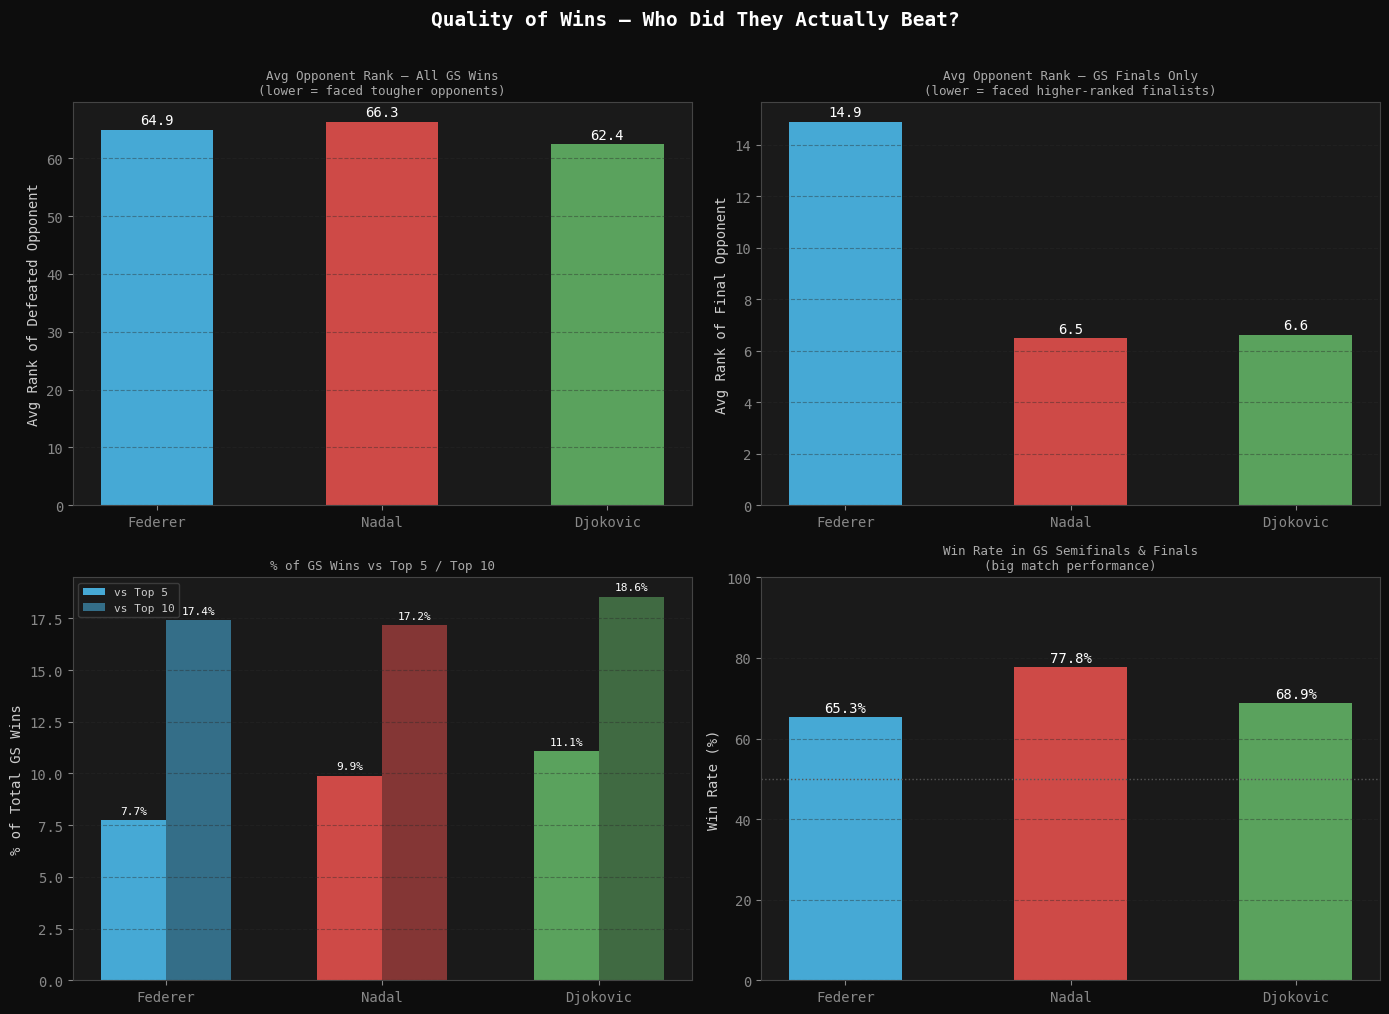

In [7]:
# Data preparation
gs     = df[df['Is_Grand_Slam']].copy()
gs_fin = gs[gs['Round'] == 'The Final']
big_rounds = ['Semifinals', 'The Final']
gs_big = gs[gs['Round'].isin(big_rounds)]

# Compute metrics
avg_opp   = {}
top5_pct  = {}
top10_pct = {}
sf_fin_wr = {}
fin_rank  = {}

for p in BIG3:
    p_gs  = gs[gs['Winner'] == p]
    total = len(p_gs)
    lr    = p_gs['Loser_Rank'].dropna()

    avg_opp[p]   = lr.mean()
    top5_pct[p]  = (lr <= 5).sum()  / total * 100
    top10_pct[p] = (lr <= 10).sum() / total * 100

    big_total    = ((gs_big['Player_1']==p)|(gs_big['Player_2']==p)).sum()
    big_wins     = (gs_big['Winner']==p).sum()
    sf_fin_wr[p] = big_wins / big_total * 100

    fin_lr       = gs_fin[gs_fin['Winner'] == p]['Loser_Rank'].dropna()
    fin_rank[p]  = fin_lr.mean()

colors = [BIG3_COLORS[p] for p in BIG3]
labels = ['Federer', 'Nadal', 'Djokovic']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Quality of Wins — Who Did They Actually Beat?',
             fontsize=14, fontweight='bold', color='white', y=1.01)

# Panel 1: Avg opponent rank — all GS wins
ax1 = axes[0, 0]
bars = ax1.bar(labels, [avg_opp[p] for p in BIG3], color=colors, alpha=0.85, width=0.5)
ax1.set_title('Avg Opponent Rank — All GS Wins\n(lower = faced tougher opponents)',
              color='#aaaaaa', fontsize=9)
ax1.set_ylabel('Avg Rank of Defeated Opponent')
ax1.grid(True, alpha=0.4, axis='y')
for bar, p in zip(bars, BIG3):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{avg_opp[p]:.1f}', ha='center', va='bottom', fontsize=10, color='white')

# Panel 2: Avg opponent rank in GS Finals
ax2 = axes[0, 1]
bars = ax2.bar(labels, [fin_rank[p] for p in BIG3], color=colors, alpha=0.85, width=0.5)
ax2.set_title('Avg Opponent Rank — GS Finals Only\n(lower = faced higher-ranked finalists)',
              color='#aaaaaa', fontsize=9)
ax2.set_ylabel('Avg Rank of Final Opponent')
ax2.grid(True, alpha=0.4, axis='y')
for bar, p in zip(bars, BIG3):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{fin_rank[p]:.1f}', ha='center', va='bottom', fontsize=10, color='white')

# Panel 3: % GS wins vs Top 5 / Top 10
ax3 = axes[1, 0]
x, w = range(len(BIG3)), 0.3
ax3.bar([i - w/2 for i in x], [top5_pct[p] for p in BIG3],
        width=w, color=colors, alpha=0.85, label='vs Top 5')
ax3.bar([i + w/2 for i in x], [top10_pct[p] for p in BIG3],
        width=w, color=colors, alpha=0.5, label='vs Top 10')
ax3.set_xticks(list(x))
ax3.set_xticklabels(labels)
ax3.set_title('% of GS Wins vs Top 5 / Top 10', color='#aaaaaa', fontsize=9)
ax3.set_ylabel('% of Total GS Wins')
ax3.legend(facecolor='#1a1a1a', edgecolor='#444444', fontsize=8)
ax3.grid(True, alpha=0.4, axis='y')
for i, p in enumerate(BIG3):
    ax3.text(i - w/2, top5_pct[p] + 0.2, f'{top5_pct[p]:.1f}%',
             ha='center', va='bottom', fontsize=8, color='white')
    ax3.text(i + w/2, top10_pct[p] + 0.2, f'{top10_pct[p]:.1f}%',
             ha='center', va='bottom', fontsize=8, color='white')

# Panel 4: SF + Final win rate
ax4 = axes[1, 1]
bars = ax4.bar(labels, [sf_fin_wr[p] for p in BIG3], color=colors, alpha=0.85, width=0.5)
ax4.set_title('Win Rate in GS Semifinals & Finals\n(big match performance)',
              color='#aaaaaa', fontsize=9)
ax4.set_ylabel('Win Rate (%)')
ax4.set_ylim(0, 100)
ax4.axhline(y=50, color='#555555', linestyle=':', linewidth=1)
ax4.grid(True, alpha=0.4, axis='y')
for bar, p in zip(bars, BIG3):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{sf_fin_wr[p]:.1f}%', ha='center', va='bottom', fontsize=10, color='white')

plt.tight_layout()
plt.show()

### What the data shows

The most surprising number here is the average rank of Federer's Grand Slam
final opponents: 14.9, compared to 6.5 for Nadal and 6.6 for Djokovic.
Across 20 finals, Federer faced opponents ranked almost 8 spots lower on
average than what Nadal and Djokovic dealt with. This doesn't diminish what
Federer achieved, but it complicates any argument that Djokovic's titles came
against weaker fields.

On Top 5 wins, Djokovic leads at 11.1% of all GS wins, ahead of Nadal (9.9%)
and Federer (7.7%). More of Djokovic's Grand Slam path ran through the
highest-ranked players in the draw.

In the semifinal and final rounds — the matches that actually decide titles —
Nadal has the highest win rate at 77.8%, which is genuinely impressive.
Djokovic sits at 68.9% and Federer at 65.3%. All three are elite, but Nadal's
big-match record at Grand Slams is the best of the three.

The "weakened competition" argument doesn't hold up here. If anything, the
data suggests Djokovic and Nadal faced tougher finals opponents than Federer did.

---

## Section 5: Match Difficulty

Win totals don't capture how hard those wins actually were. Two metrics
help here: match difficulty (straight sets vs four or five sets), and
betting odds as a proxy for pre-match expectations.

If Djokovic was routinely winning easy — against weak opponents who were
past their prime — we'd expect a high straight-sets rate and almost no
underdog wins. Let's check.

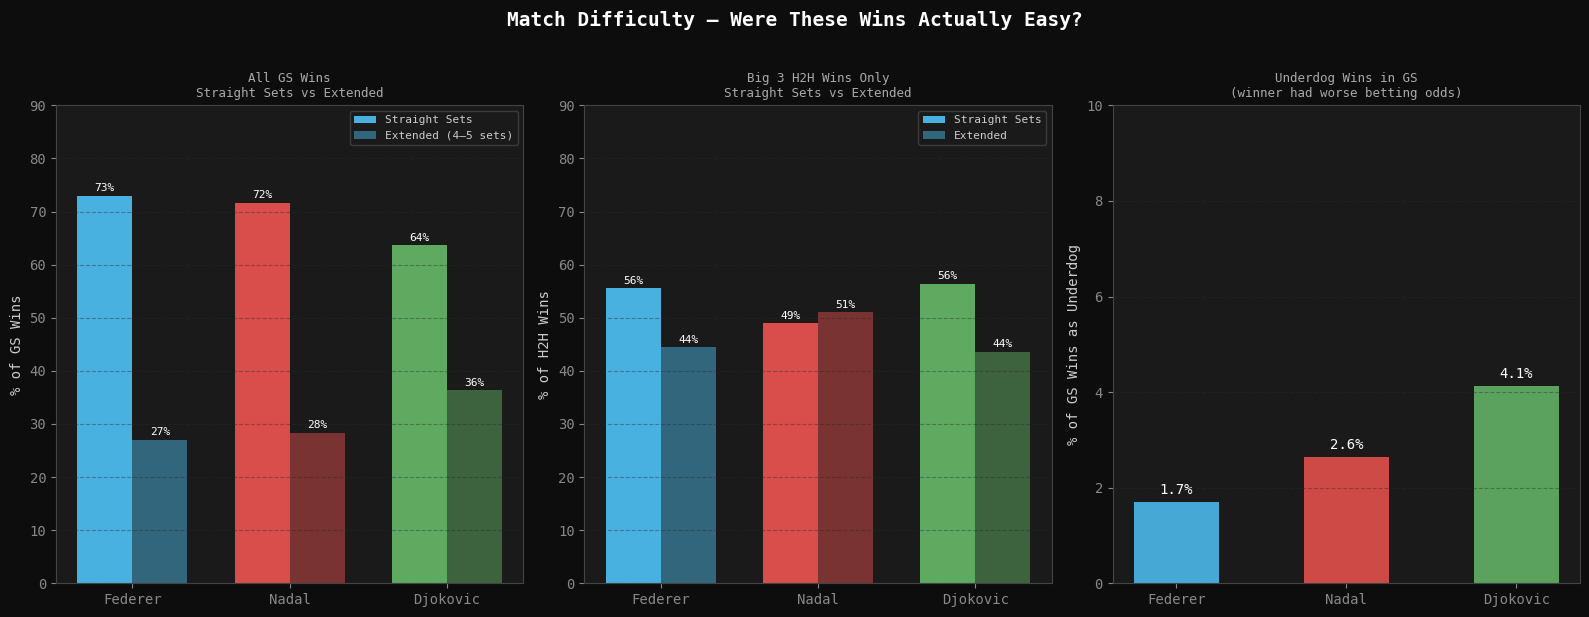

In [8]:
gs  = df[df['Is_Grand_Slam']].copy()
h2h = df[df['Player_1'].isin(BIG3) & df['Player_2'].isin(BIG3)].copy()
gs_odds = gs.dropna(subset=['Winner_Odd', 'Loser_Odd'])

# Compute metrics
ss_pct       = {}
ext_pct      = {}
h2h_ss_pct   = {}
h2h_ext_pct  = {}
underdog_pct = {}

for p in BIG3:
    p_gs    = gs[gs['Winner'] == p]
    total   = len(p_gs)
    ss_pct[p]  = (p_gs['Match_Difficulty'] == 'Straight Sets').sum() / total * 100
    ext_pct[p] = (p_gs['Match_Difficulty'] == 'Extended').sum()      / total * 100

    p_h2h   = h2h[h2h['Winner'] == p]
    h_total = len(p_h2h)
    h2h_ss_pct[p]  = (p_h2h['Match_Difficulty'] == 'Straight Sets').sum() / h_total * 100
    h2h_ext_pct[p] = (p_h2h['Match_Difficulty'] == 'Extended').sum()      / h_total * 100

    p_odds  = gs_odds[gs_odds['Winner'] == p]
    underdog_pct[p] = p_odds['Underdog_Win'].sum() / len(p_odds) * 100

colors = [BIG3_COLORS[p] for p in BIG3]
labels = ['Federer', 'Nadal', 'Djokovic']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Match Difficulty — Were These Wins Actually Easy?',
             fontsize=14, fontweight='bold', color='white', y=1.02)

# Panel 1: GS wins — Straight Sets vs Extended
ax1 = axes[0]
x, w = np.arange(len(BIG3)), 0.35
bars_ss  = ax1.bar(x - w/2, [ss_pct[p]  for p in BIG3], width=w,
                   color=colors, alpha=0.9,  label='Straight Sets')
bars_ext = ax1.bar(x + w/2, [ext_pct[p] for p in BIG3], width=w,
                   color=colors, alpha=0.45, label='Extended (4–5 sets)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('% of GS Wins')
ax1.set_title('All GS Wins\nStraight Sets vs Extended', color='#aaaaaa', fontsize=9)
ax1.legend(facecolor='#1a1a1a', edgecolor='#444444', fontsize=8)
ax1.grid(True, alpha=0.4, axis='y')
ax1.set_ylim(0, 90)
for bar, p in zip(bars_ss, BIG3):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{ss_pct[p]:.0f}%', ha='center', va='bottom', fontsize=8, color='white')
for bar, p in zip(bars_ext, BIG3):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{ext_pct[p]:.0f}%', ha='center', va='bottom', fontsize=8, color='white')

# Panel 2: H2H Big 3 wins — difficulty
ax2 = axes[1]
bars_ss2  = ax2.bar(x - w/2, [h2h_ss_pct[p]  for p in BIG3], width=w,
                    color=colors, alpha=0.9,  label='Straight Sets')
bars_ext2 = ax2.bar(x + w/2, [h2h_ext_pct[p] for p in BIG3], width=w,
                    color=colors, alpha=0.45, label='Extended')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('% of H2H Wins')
ax2.set_title('Big 3 H2H Wins Only\nStraight Sets vs Extended', color='#aaaaaa', fontsize=9)
ax2.legend(facecolor='#1a1a1a', edgecolor='#444444', fontsize=8)
ax2.grid(True, alpha=0.4, axis='y')
ax2.set_ylim(0, 90)
for bar, p in zip(bars_ss2, BIG3):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{h2h_ss_pct[p]:.0f}%', ha='center', va='bottom', fontsize=8, color='white')
for bar, p in zip(bars_ext2, BIG3):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{h2h_ext_pct[p]:.0f}%', ha='center', va='bottom', fontsize=8, color='white')

# Panel 3: Underdog wins in GS
ax3 = axes[2]
bars3 = ax3.bar(labels, [underdog_pct[p] for p in BIG3],
                color=colors, alpha=0.85, width=0.5)
ax3.set_ylabel('% of GS Wins as Underdog')
ax3.set_title('Underdog Wins in GS\n(winner had worse betting odds)', color='#aaaaaa', fontsize=9)
ax3.grid(True, alpha=0.4, axis='y')
ax3.set_ylim(0, 10)
for bar, p in zip(bars3, BIG3):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{underdog_pct[p]:.1f}%', ha='center', va='bottom', fontsize=10, color='white')

plt.tight_layout()
plt.show()

### What the data shows

Across all Grand Slam wins, Djokovic actually went to extended matches
(4 or 5 sets) more often than either Federer or Nadal — 36.3% of his
wins compared to 28.4% for Nadal and 27.1% for Federer. The "easy wins"
narrative doesn't hold up against that number.

In direct Big 3 head-to-head matches specifically, all three players
are close: Nadal went extended in 51% of his wins against the other two,
Federer 44.4%, Djokovic 43.6%. These were hard-fought matches across
the board, not lopsided results.

The underdog chart adds another layer. Djokovic won as the betting
underdog in 4.1% of his Grand Slam matches — more than twice Federer's
rate (1.7%) and meaningfully higher than Nadal's (2.6%). He wasn't
always the favorite walking onto the court.

Taken together, Sections 3, 4, and 5 consistently push back against
the same claim: that Djokovic's record was built on easy matches against
declining rivals. The data shows competitive rivalries, tough opponents
in finals, and a higher rate of grinding through long matches than his
peers. The title count is bigger. The difficulty doesn't appear to be lower.

---

## Section 6: Conclusions & Caveats

### What the data actually says

This analysis started with one specific claim: that Djokovic's Grand Slam
record was inflated by facing Federer and Nadal past their primes. Five
sections of data later, here's where that argument stands.

**The prime era overlap is real — but incomplete.**
Federer dominated from roughly 2004–2010. Nadal had two distinct peaks:
2005–2011 and again 2017–2020. Djokovic's rise begins in 2011 and stays
elite through 2023. There is genuine overlap, especially with Nadal's
second prime. The claim isn't entirely wrong — Djokovic did accumulate
titles in years where Federer was declining. But he also won during years
where Nadal was very much at his best.

**The head-to-head record doesn't support "easy wins".**
Overall, Djokovic leads Federer 26–20 and Nadal 29–25. Neither rivalry
was a walkover. In Grand Slams specifically, Nadal actually leads Djokovic
9–7 in direct matchups — a number that rarely comes up in the title count
debate. On clay, Nadal beats Djokovic 18–8 across their entire careers.

**The quality of opposition holds up.**
Djokovic's Grand Slam final opponents were ranked 6.6 on average — nearly
identical to Nadal's 6.5, and significantly tougher than Federer's 14.9.
He also leads in percentage of GS wins against Top 5 opponents (11.1% vs
9.9% vs 7.7%). If the field was weak, it doesn't show up in the rankings
of the players he beat.

**The matches themselves weren't easy.**
Djokovic went to extended matches (4 or 5 sets) in 36.3% of his Grand
Slam wins — more than Nadal (28.4%) and Federer (27.1%). He also won as
the betting underdog more than twice as often as Federer. These aren't
the numbers of someone coasting through a depleted draw.

---

### What the data cannot tell us

A few things that are genuinely outside the scope of this analysis:

- **Era differences.** Federer's dominance came in an era with fewer
  baseline grinders and a different physical style of play. Whether that
  made winning easier or harder is a legitimate debate that stats can't
  fully resolve.

- **Injuries and absences.** Several of Federer's and Nadal's best years
  were cut short by injury. What their records would look like fully
  healthy is unknowable.

- **Draw luck.** Aggregate statistics smooth out individual tournament
  draws. A player can face an unusually soft path to a title without it
  showing clearly in the yearly averages.

- **The "what if" question.** What if Federer and Nadal had played in
  their absolute prime against Djokovic in his? That match never happened,
  and no dataset can simulate it.

---

### The bottom line

The data doesn't settle the GOAT debate — nothing will, because part of
it is subjective. But it does answer the specific question this analysis
set out to test.

The claim that Djokovic's record is a product of weakened competition
doesn't survive contact with the numbers. He beat both rivals when they
were competitive, faced tougher opponents in finals than Federer did,
won more often in long matches, and has more Grand Slam titles than anyone
in history.

Whether that makes him the GOAT is up to you. What the data says is that
he earned the count.

---

*Dataset: [ATP Tennis 2000–2023, Kaggle](https://www.kaggle.com/datasets/dissfya/atp-tennis-2000-2023daily-pull)*
*Analysis by: YGX*